In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

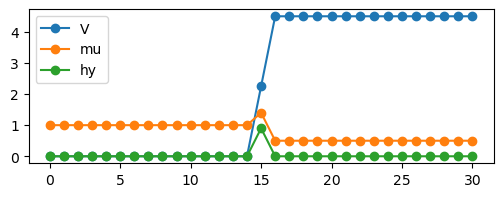

In [2]:
widthS = 15
widthF1 = 1
widthF2 = 15
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthF2] = muN
mu[widthF2:widthF2+widthF1] = muF
mu[widthF2+widthF1:] = muS

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U=None

V0 = 4.5 * t
V = V0 * np.ones(lattice.X)
V[:widthF1 + widthF2] = 0
V[widthS] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1], hy=hy)

In [4]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.07788745236738297
Relative error: 77887452367.38295
Average old: 0j
Average: (0.007409013486137817+1.0418828725244596e-17j)
F_xplus:
Absolute error: 0.7033036585982181
Relative error: 28256337487.108715
Average old: (0.053333333333333344+0j)
Average: (0.1426948041768421-1.2738239109324953e-17j)
F_xmin:
Absolute error: 0.726001245090121
Relative error: 74020961159.87238
Average old: (0.05000000000000002+0j)
Average: (0.1496173256719341-1.0626177874695925e-17j)
F_yplus:
Absolute error: 0.7162673184873167
Relative error: 68789856328.34142
Average old: (-0.051612903225806465+0j)
Average: (-0.14962919534455857+5.954099490926472e-17j)
F_ymin:
Absolute error: 0.7162673184873168
Relative error: 68789856328.34161
Average old: (-0.051612903225806465+0j)
Average: (-0.14962919534455857-5.20388748438074e-17j)
Fuu_xplus:
Absolute error: 0.07325310044823914
Relative error: 73253100448.23914
Average old: 0j
Average: (1.2849700904030024e-18+0.007289991777207647j)
Fuu_xmin:
Absolut

In [5]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


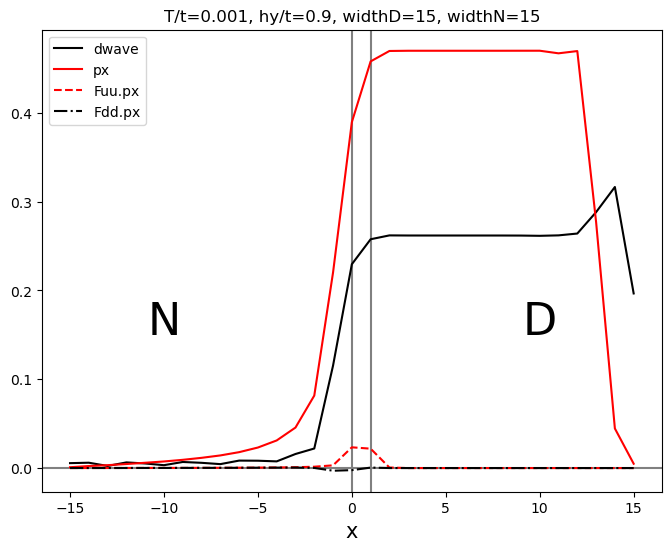

In [6]:
x = np.arange(-widthF2, widthF1+widthS)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
axs.plot(x, np.abs(F.px), label=r"px", color='red')
axs.plot(x, np.imag(Fuu.px), "--", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "-.", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)

# axs.set_ylim(None, 0.10)
# axs.set_xlim(-5, 10)
# axs.set_xticks([-5, 0, 5, 10])
axs.text(-10, 0.15, "N", fontsize=32, horizontalalignment='center')
axs.text(10, 0.15, "D", fontsize=32, horizontalalignment='center')

axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthS}, widthN={widthF2}", )
plt.legend()
plt.show()

T/t=0.001, hy/t=0.9


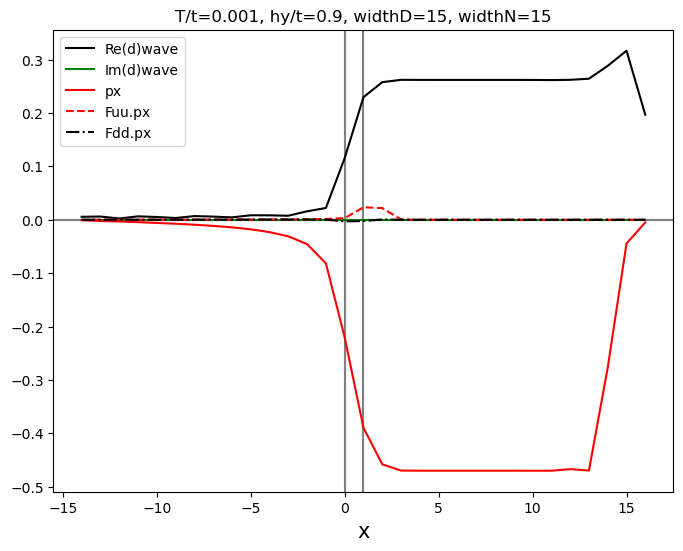

In [7]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.real(F.dwave), label=r"Re(d)wave", color='black')
axs.plot(x, np.imag(F.dwave), label=r"Im(d)wave", color='green')
axs.plot(x, np.real(F.px), label=r"px", color='red')
axs.plot(x, np.imag(Fuu.px), "--", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "-.", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)

# axs.set_ylim(None, 0.10)
# axs.set_xlim(-5, 10)
# axs.set_xticks([-5, 0, 5, 10])
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthS}, widthN={widthF2}", )
plt.legend()
plt.show()